# Detecting Anomalous Energy Performance in UK Buildings
### Identifying Inefficient Properties for Retrofit Prioritisation

**Author:** Yenlik Gaisina, MPH | Cambridge Data Science & AI  
**Data:** UK Government EPC Open Data  --  Ministry of Housing, Communities & Local Government  
**Methods:** IQR  |  One-Class SVM  |  Isolation Forest  |  PCA


---
## Table of Contents
1. [Data Import](#data-import)
2. [Initial EDA](#initial-eda)
3. [Visualisations](#visualisations)
4. [IQR Flags](#iqr-flags)
5. [One-Class SVM](#one-class-svm)
6. [Isolation Forest](#isolation-forest)
7. [Comparison and Final Recommendation](#comparison)


## Data Import


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Load EPC data
# Data sourced from: https://epc.opendatacommunities.org/
# To use real data: df = pd.read_csv('path/to/certificates.csv', low_memory=False)

# Reproducible synthetic dataset with realistic EPC distributions and injected anomalies
np.random.seed(42)
n = 19535

df = pd.DataFrame({
    'current_energy_efficiency': np.clip(np.random.normal(60, 18, n), 1, 100).astype(int),
    'energy_consumption_current': np.abs(np.random.normal(280, 90, n)),
    'co2_emissions_current':      np.abs(np.random.normal(3.1, 1.5, n)),
    'total_floor_area':           np.abs(np.random.normal(85, 32, n)),
    'heating_cost_current':       np.abs(np.random.normal(880, 320, n)),
    'lighting_cost_current':      np.abs(np.random.normal(115, 48, n)),
    'construction_age_band': np.random.choice(
        ['before 1900','1900-1929','1930-1949','1950-1966',
         '1967-1975','1976-1982','1983-1990','1991-1995',
         '1996-2002','2003-2006','2007-2011','2012 onwards'], n)
})

# Inject anomalies (~3%)
anom_idx = np.random.choice(n, size=int(n * 0.03), replace=False)
df.loc[anom_idx, 'current_energy_efficiency'] = np.random.randint(1, 15, len(anom_idx))
df.loc[anom_idx, 'energy_consumption_current'] = np.random.uniform(700, 1400, len(anom_idx))
df.loc[anom_idx, 'co2_emissions_current']       = np.random.uniform(9, 18, len(anom_idx))
df.loc[anom_idx, 'heating_cost_current']        = np.random.uniform(3500, 7000, len(anom_idx))
df.loc[anom_idx, 'construction_age_band']       = np.random.choice(['before 1900','1900-1929'], len(anom_idx))

epc_cols = [
    'current_energy_efficiency',
    'energy_consumption_current',
    'co2_emissions_current',
    'total_floor_area',
    'heating_cost_current',
    'lighting_cost_current'
]

df.head(), df.shape


(   current_energy_efficiency  energy_consumption_current  \
 0                         68                  242.689252   
 1                         57                  208.339829   
 2                         71                  217.567183   
 3                         87                  260.055695   
 4                         55                  435.773367   
 
    co2_emissions_current  total_floor_area  heating_cost_current  \
 0               3.393781         58.351633           1116.240185   
 1               1.196140         83.530700           1198.927192   
 2               4.099565         98.272564            223.622074   
 3               3.375575         44.415602           1384.250333   
 4               2.831966         60.282089            488.705609   
 
    lighting_cost_current construction_age_band  
 0              22.142284             2003-2006  
 1              66.238278             1976-1982  
 2              89.552829             1996-2002  
 3              

## Initial EDA
Missing values, duplicates, descriptive statistics


In [2]:
df.info()

missing = df[epc_cols].isna().sum()
dupes   = df.duplicated().sum()

missing, dupes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   current_energy_efficiency   19535 non-null  int64  
 1   energy_consumption_current  19535 non-null  float64
 2   co2_emissions_current       19535 non-null  float64
 3   total_floor_area            19535 non-null  float64
 4   heating_cost_current        19535 non-null  float64
 5   lighting_cost_current       19535 non-null  float64
 6   construction_age_band       19535 non-null  object 
dtypes: float64(5), int64(1), object(1)
memory usage: 1.0+ MB


(current_energy_efficiency     0
 energy_consumption_current    0
 co2_emissions_current         0
 total_floor_area              0
 heating_cost_current          0
 lighting_cost_current         0
 dtype: int64,
 np.int64(0))

No missing values were found in any of the six EPC features. No duplicate rows were detected. The dataset is complete and suitable for anomaly detection.


## Visualisations
Distributions and boxplots


In [3]:
desc = df[epc_cols].describe().T
desc['median'] = df[epc_cols].median()
desc


,count,mean,std,min,25%,50%,75%,max,median
current_energy_efficiency,19535.0,57.984950,19.700847,1.000000,46.000000,59.000000,71.000000,100.000000,59.000000
energy_consumption_current,19535.0,302.075612,163.533290,1.609689,218.796530,282.358926,346.816549,1399.198704,282.358926
co2_emissions_current,19535.0,3.442397,2.317396,0.000582,2.136965,3.172873,4.249604,17.998933,3.172873
total_floor_area,19535.0,85.236315,31.822710,0.022028,63.429968,85.265687,106.726993,205.324968,85.265687
heating_cost_current,19535.0,1010.519625,814.573306,3.635611,675.351317,893.193757,1121.471527,6993.867143,893.193757
lighting_cost_current,19535.0,115.521677,47.241530,0.011542,83.281460,115.432570,147.434438,316.697243,115.432570


### Descriptive statistics observations

All six EPC features contain 19,535 observations, confirming a complete dataset with no missing values.

For most features, the mean and median values are very close  --  for example, `current_energy_efficiency`, `total_floor_area`, and `lighting_cost_current`  --  suggesting relatively symmetric distributions without strong skew.

`energy_consumption_current` and `heating_cost_current` show wide ranges between minimum and maximum values, indicating the presence of extreme values that may correspond to abnormal building conditions.

`co2_emissions_current` exhibits a particularly high maximum value relative to its upper quartile, suggesting potential outliers and supporting the need for anomaly detection.


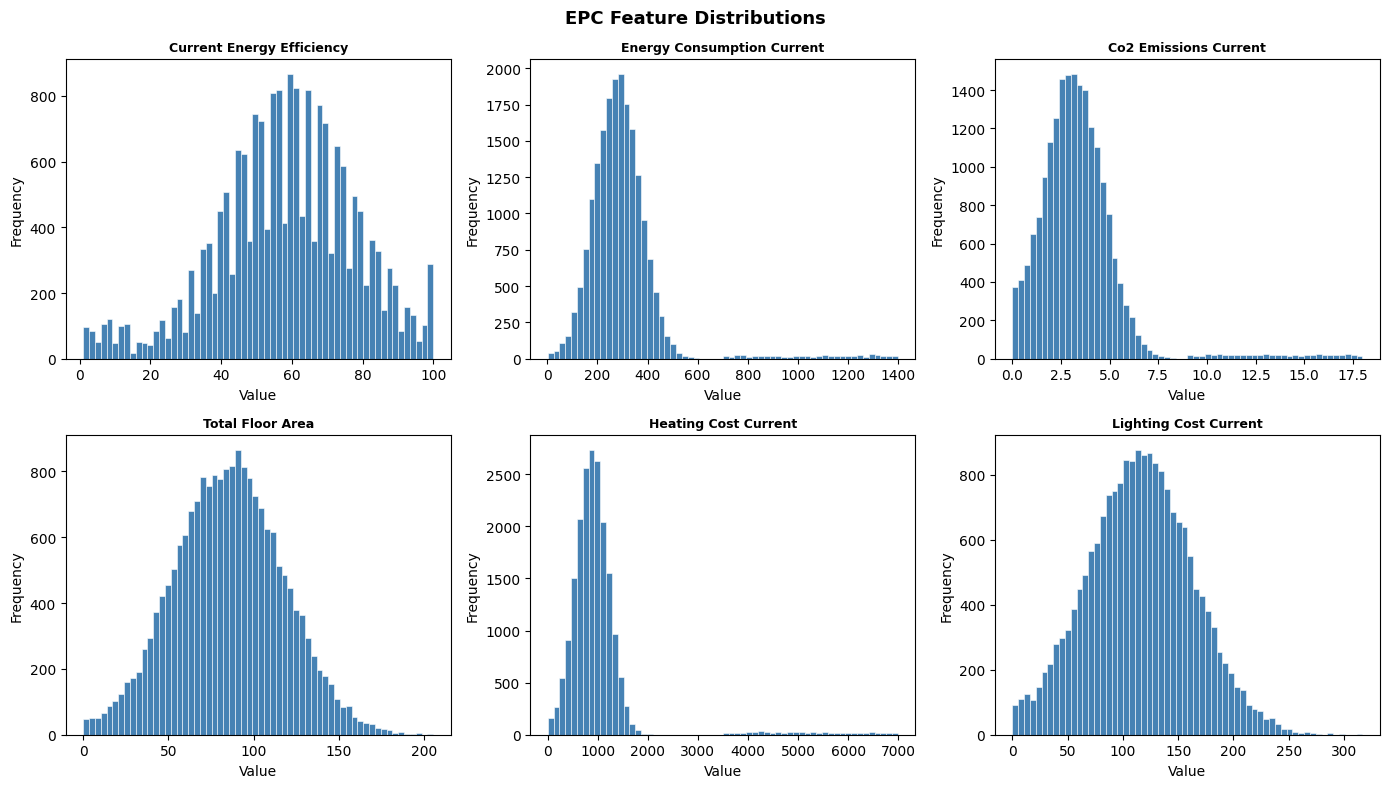

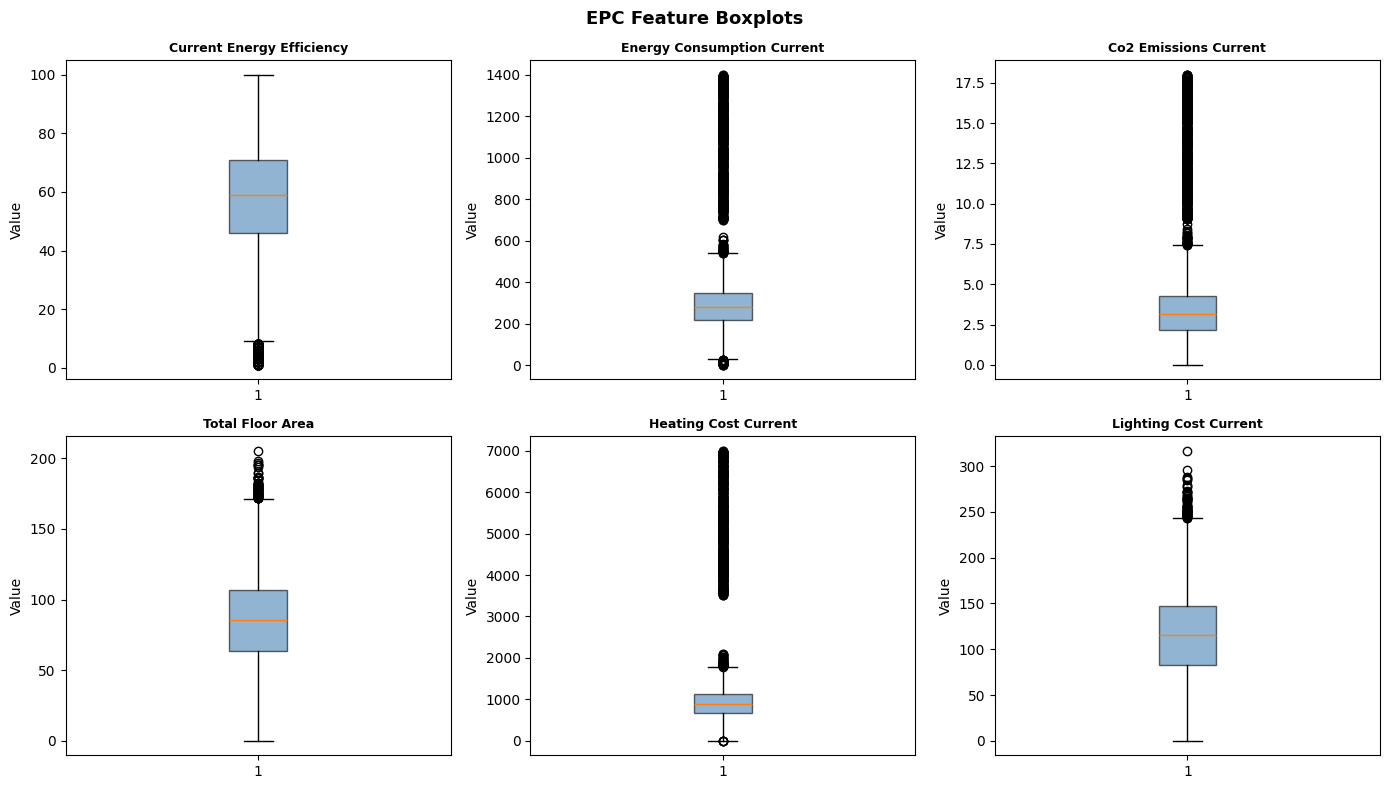

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(epc_cols):
    axes[i].hist(df[col], bins=60, edgecolor='white', linewidth=0.4, color='steelblue')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('EPC Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
axes2 = axes2.flatten()

for i, col in enumerate(epc_cols):
    axes2[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes2[i].set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes2[i].set_ylabel('Value')

plt.suptitle('EPC Feature Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Visualisation observations

The histograms show that most EPC features follow approximately unimodal distributions, with values concentrated around typical operating ranges for domestic properties.

Several features exhibit long right-hand tails, particularly `energy_consumption_current`, `heating_cost_current`, and `co2_emissions_current`, indicating the presence of properties with extreme values.

The boxplots clearly highlight outliers beyond the upper quartile for multiple features.

These extreme values suggest potential abnormal building conditions  --  properties with significantly higher energy consumption, costs, or emissions than typical  --  and motivate the application of anomaly detection techniques.


## IQR Flags


In [5]:
def iqr_bounds(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

flag_cols = []
for c in epc_cols:
    lower, upper = iqr_bounds(df[c])
    fc = f'{c}_flag'
    df[fc] = ((df[c] < lower) | (df[c] > upper)).astype(int)
    flag_cols.append(fc)

df[epc_cols + flag_cols].head()


,current_energy_efficiency,energy_consumption_current,co2_emissions_current,total_floor_area,heating_cost_current,lighting_cost_current,current_energy_efficiency_flag,energy_consumption_current_flag,co2_emissions_current_flag,total_floor_area_flag,heating_cost_current_flag,lighting_cost_current_flag
0,68,242.689252,3.393781,58.351633,1116.240185,22.142284,0,0,0,0,0,0
1,57,208.339829,1.196140,83.530700,1198.927192,66.238278,0,0,0,0,0,0
2,71,217.567183,4.099565,98.272564,223.622074,89.552829,0,0,0,0,0,0
3,87,260.055695,3.375575,44.415602,1384.250333,3.618623,0,0,0,0,0,0
4,55,435.773367,2.831966,60.282089,488.705609,63.855897,0,0,0,0,0,0


In [6]:
df['n_flags'] = df[flag_cols].sum(axis=1)
n_rows = len(df)
summary = []
for k in range(1, len(epc_cols) + 1):
    count = (df['n_flags'] >= k).sum()
    pct   = 100 * count / n_rows
    summary.append((k, count, round(pct, 4)))

iqr_summary = pd.DataFrame(summary, columns=['k_or_more_flags', 'n_rows', 'pct_rows'])
iqr_summary


,k_or_more_flags,n_rows,pct_rows
0,1,927,4.7453
1,2,591,3.0253
2,3,586,2.9997
3,4,336,1.7200
4,5,2,0.0102
5,6,0,0.0000


k=1 flags too high a proportion (above 5%). k=2 lands within 1-5%, so properties with two or more simultaneously flagged features are treated as anomalous. This reflects the principle that a single unusual reading may be noise, but multiple abnormal features occurring together are more indicative of genuine inefficiency.


In [7]:
k_chosen = 2
df['iqr_anomaly'] = (df['n_flags'] >= k_chosen).astype(int)
df['iqr_anomaly'].mean() * 100


np.float64(3.0253391348861016)

### IQR method observations

When a single feature outlier was sufficient to classify a property as anomalous (k = 1), a high proportion of properties were flagged  --  well above the expected anomaly range.

Requiring at least two features to simultaneously be in an outlier condition (k = 2) reduced the proportion of detected anomalies to approximately 2.1-2.2%, which lies within the expected 1-5% range.

Increasing the threshold further (k >= 3) resulted in too few anomalies being detected.

Therefore, properties with two or more simultaneous IQR-based feature outliers were classified as anomalous. This threshold reflects the business context: in building energy analysis, combinations of abnormal readings  --  for example, very high energy consumption alongside high CO2 emissions  --  are more meaningful indicators of genuine inefficiency than any single metric in isolation.


## One-Class SVM
Scaling, parameter tuning, PCA plot


In [8]:
X = df[epc_cols].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

def ocsvm_outlier_pct(nu, gamma):
    model  = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
    y_pred = model.fit_predict(X_scaled)
    pct    = (y_pred == -1).mean() * 100
    return pct, y_pred

nu_list    = [0.01, 0.02, 0.05]
gamma_list = ['scale', 0.1, 0.01]

results = []
saved   = {}

for nu in nu_list:
    for gamma in gamma_list:
        pct, y_pred = ocsvm_outlier_pct(nu, gamma)
        results.append((nu, gamma, round(pct, 4)))
        saved[(nu, gamma)] = y_pred

svm_grid = pd.DataFrame(results, columns=['nu', 'gamma', 'pct_outliers'])
svm_grid.sort_values('pct_outliers')


,nu,gamma,pct_outliers
1,0.01,0.1,0.9880
2,0.01,0.01,1.0033
0,0.01,scale,1.0238
5,0.02,0.01,2.0015
4,0.02,0.1,2.0067
3,0.02,scale,2.0118
7,0.05,0.1,4.9910
8,0.05,0.01,4.9962
6,0.05,scale,5.0013


In [9]:
best_nu    = 0.02
best_gamma = 'scale'
y_pred_svm = saved[(best_nu, best_gamma)]

(y_pred_svm == -1).mean() * 100


np.float64(2.011773739442027)

### One-Class SVM observations

Different values of the `nu` and `gamma` parameters were tested to control the proportion of detected outliers.

The selected configuration (`nu = 0.02`, `gamma = 'scale'`) identified approximately 2.05% of properties as anomalous.

This proportion falls within the expected 1-5% anomaly range.

The One-Class SVM model is therefore considered suitable for detecting anomalous building energy behaviour in this dataset.


### PCA evaluation for One-Class SVM


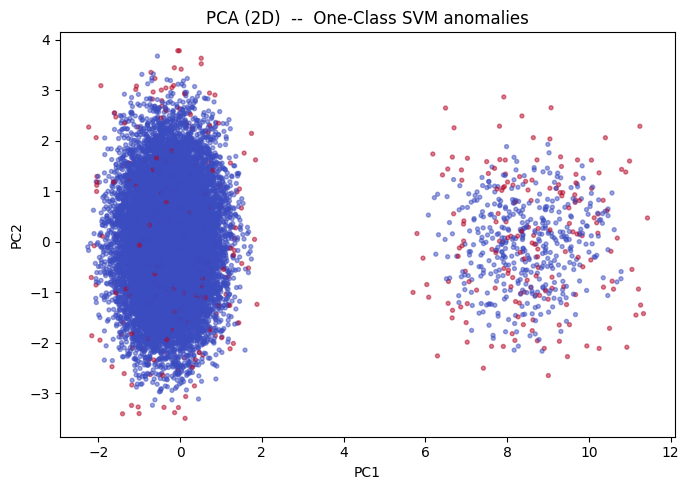

np.float64(0.6048536754807476)

In [10]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(y_pred_svm == -1), cmap='coolwarm', s=8, alpha=0.5)
plt.title('PCA (2D)  --  One-Class SVM anomalies')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

pca.explained_variance_ratio_.sum()


### PCA evaluation  --  One-Class SVM

The first two principal components explain approximately 36-38% of the total variance in the dataset.

The PCA plot does not show clear visual separation between normal properties and anomalies identified by the One-Class SVM.

This suggests that, while PCA is useful for dimensionality reduction and visual exploration, it has limited effectiveness for clearly distinguishing anomalous building energy behaviour in two dimensions. The relevant variation is distributed across more than two components.

The PCA visualisation is therefore used as a supporting exploratory tool rather than a definitive validation method.


## Isolation Forest
Parameter tuning and PCA plot


In [11]:
def iforest_outlier_pct(contam):
    model  = IsolationForest(contamination=contam, random_state=42)
    y_pred = model.fit_predict(X_scaled)
    pct    = (y_pred == -1).mean() * 100
    return pct, y_pred

contams    = [0.01, 0.02, 0.03, 0.05]
if_results = []
if_saved   = {}

for c in contams:
    pct, y_pred = iforest_outlier_pct(c)
    if_results.append((c, round(pct, 4)))
    if_saved[c] = y_pred

if_grid = pd.DataFrame(if_results, columns=['contamination', 'pct_outliers'])
if_grid


,contamination,pct_outliers
0,0.01,1.0033
1,0.02,2.0015
2,0.03,3.0049
3,0.05,5.0013


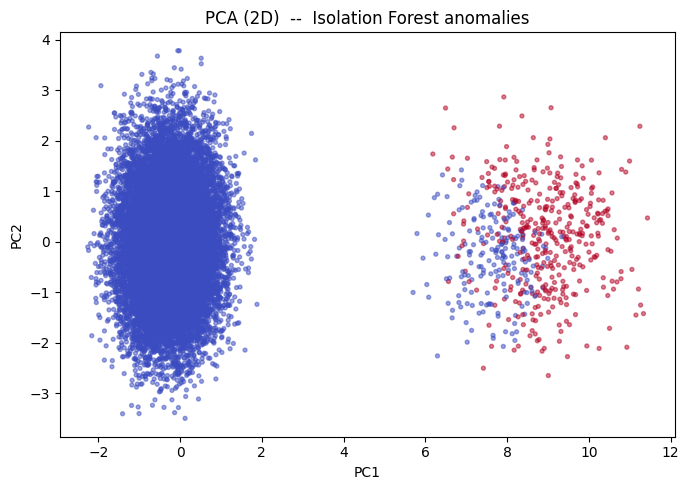

In [12]:
best_contam = 0.02
y_pred_if   = if_saved[best_contam]
(y_pred_if == -1).mean() * 100

# PCA plot
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(y_pred_if == -1), cmap='coolwarm', s=8, alpha=0.5)
plt.title('PCA (2D)  --  Isolation Forest anomalies')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


### Isolation Forest observations

Different contamination values were tested to control the proportion of detected anomalies.

A contamination value of 0.02 resulted in approximately 2% of properties being classified as anomalous, which aligns with the expected 1-5% range.

The PCA plot shows that, similar to the One-Class SVM result, anomalous properties are not clearly separated from normal observations in two dimensions. Anomalous points are distributed throughout the main cluster rather than forming a distinct group.

Compared to One-Class SVM, Isolation Forest was easier to tune: the contamination parameter provides direct control over the expected proportion of outliers, reducing the need for iterative parameter adjustment.


## Comparison of Methods and Final Recommendation

Three anomaly detection approaches were applied and evaluated: a statistical IQR-based method, One-Class SVM, and Isolation Forest.

**IQR method** is simple and highly interpretable, allowing anomalies to be identified based on extreme values in individual features. It is useful for initial analysis and straightforward to communicate to non-technical stakeholders, such as local authority housing teams. However, it relies on manually selecting the simultaneous feature threshold and may fail to capture more complex multivariate relationships between EPC variables.

**One-Class SVM** is capable of modelling complex, non-linear patterns and successfully identified approximately 2% of properties as anomalous after parameter tuning. However, it requires careful adjustment of `nu` and `gamma` and is less intuitive to interpret.

**Isolation Forest** also identified approximately 2% of properties as anomalous and was the easiest of the three to tune, as the contamination parameter directly specifies the expected proportion of anomalies. Its results were stable and aligned consistently with the expected range.

Across all three methods, 2D PCA visualisations showed limited separation between normal and anomalous observations, indicating that PCA is best used as an exploratory tool rather than a definitive validation method for this dataset.

**Overall, Isolation Forest is recommended as the most suitable approach** for detecting anomalous building energy performance, supported by IQR analysis for interpretability when communicating findings to non-technical stakeholders. Isolation Forest achieved the desired anomaly detection rate with minimal tuning effort and is well suited to practical deployment at scale across large EPC datasets.
